<a href="https://colab.research.google.com/github/Kavishka2401/CustomerChurnPredictionSystem/blob/master/Final_NN_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Mount the google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [50]:
# Core libraries
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

# Scikit-learn libraries
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    f1_score,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    classification_report
)
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

# TensorFlow / Keras libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import AUC, Precision, Recall
from tensorflow.keras.regularizers import l2

## Import X and Y Splits

In [3]:
# Path to saved splits
project_path = '/content/drive/MyDrive/NN_Model/Data_Splits/'

# Load train/test splits
with open(project_path + 'X_train.pkl', 'rb') as f:
    X_train = pickle.load(f)

with open(project_path + 'X_test.pkl', 'rb') as f:
    X_test = pickle.load(f)

with open(project_path + 'y_train.pkl', 'rb') as f:
    y_train = pickle.load(f)

with open(project_path + 'y_test.pkl', 'rb') as f:
    y_test = pickle.load(f)

print("Data loaded successfully!")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

Data loaded successfully!
X_train shape: (5634, 17)
X_test shape: (1409, 17)


## Manual Split for Validation

In [4]:
# Split X_train and Y_train into train + validation sets
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

## Function to Train Model

In [5]:
def train_nn_model(X_train, y_train, X_val, y_val, seed=42):
    # Compute class weights on original training data
    classes = np.unique(y_train)
    class_weights_values = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
    class_weight_dict = dict(zip(classes, class_weights_values))

    # Initialize model
    model = Sequential([
        Dense(32, activation='relu', input_shape=(X_train.shape[1],), kernel_regularizer=l2(0.002)),
        Dropout(0.2, seed=seed),
        Dense(16, activation='relu', kernel_regularizer=l2(0.002)),
        Dropout(0.2, seed=seed),
        Dense(1, activation='sigmoid')
    ])

    # Compile model
    model.compile(
        optimizer=Adam(learning_rate=0.0005),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    # Callbacks
    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)

    # Train
    history = model.fit(
        X_train, y_train,
        epochs=100,
        batch_size=32,
        validation_data=(X_val, y_val),
        class_weight=class_weight_dict,
        callbacks=[early_stop, reduce_lr],
        verbose=1
    )

    return model, class_weight_dict, history

## Function to Evaluate Model

In [6]:
def evaluate_nn_model(model, X_train, y_train, X_val, y_val, X_test, y_test, history):
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np
    from sklearn.metrics import (
        accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
        classification_report, confusion_matrix, roc_curve, precision_recall_curve, average_precision_score
    )

    # Predict probabilities
    y_train_probs = model.predict(X_train).ravel()
    y_val_probs = model.predict(X_val).ravel()
    y_test_probs = model.predict(X_test).ravel()

    # Find best threshold based on validation F1
    thresholds = np.arange(0.1, 0.9, 0.01)
    best_threshold = 0.5
    best_f1 = 0
    for t in thresholds:
        preds = (y_val_probs > t).astype(int)
        f1 = f1_score(y_val, preds)
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = t
    print("Best Threshold based on validation set:", best_threshold)

    # Apply threshold
    y_train_pred = (y_train_probs > best_threshold).astype(int)
    y_val_pred = (y_val_probs > best_threshold).astype(int)
    y_test_pred = (y_test_probs > best_threshold).astype(int)

    # Metrics function
    def calc_metrics(y_true, y_pred, y_prob):
        acc = accuracy_score(y_true, y_pred)
        prec = precision_score(y_true, y_pred)
        rec = recall_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred)
        roc_auc = roc_auc_score(y_true, y_prob)
        return acc, prec, rec, f1, roc_auc

    # Calculate metrics
    train_acc, train_prec, train_rec, train_f1, train_roc = calc_metrics(y_train, y_train_pred, y_train_probs)
    val_acc, val_prec, val_rec, val_f1, val_roc = calc_metrics(y_val, y_val_pred, y_val_probs)
    test_acc, test_prec, test_rec, test_f1, test_roc = calc_metrics(y_test, y_test_pred, y_test_probs)

    # Compute losses
    train_loss = model.evaluate(X_train, y_train, verbose=0)[0]
    val_loss = model.evaluate(X_val, y_val, verbose=0)[0]
    test_loss = model.evaluate(X_test, y_test, verbose=0)[0]

    # Print metrics
    print("--------TRAIN METRICS--------")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train Accuracy: {train_acc:.4f}")
    print(f"Train Precision: {train_prec:.4f}")
    print(f"Train Recall: {train_rec:.4f}")
    print(f"Train F1 Score: {train_f1:.4f}")
    print(f"Train ROC-AUC: {train_roc:.4f}")

    print("\n--------VALIDATION METRICS--------")
    print(f"Val Loss: {val_loss:.4f}")
    print(f"Val Accuracy: {val_acc:.4f}")
    print(f"Val Precision: {val_prec:.4f}")
    print(f"Val Recall: {val_rec:.4f}")
    print(f"Val F1 Score: {val_f1:.4f}")
    print(f"Val ROC-AUC: {val_roc:.4f}")

    print("\n--------TEST METRICS--------")
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")
    print(f"Test Precision: {test_prec:.4f}")
    print(f"Test Recall: {test_rec:.4f}")
    print(f"Test F1 Score: {test_f1:.4f}")
    print(f"Test ROC-AUC: {test_roc:.4f}")

    # Classification Reports
    print("\nTrain Classification Report:\n", classification_report(y_train, y_train_pred))
    print("\nValidation Classification Report:\n", classification_report(y_val, y_val_pred))
    print("\nTest Classification Report:\n", classification_report(y_test, y_test_pred))

    # Confusion Matrix Heatmap
    cm = confusion_matrix(y_test, y_test_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix - Test Set")
    plt.show()

    # ROC Curve for Test Set
    fpr, tpr, _ = roc_curve(y_test, y_test_probs)
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f'ROC curve (AUC={test_roc:.3f})', color='blue')
    plt.plot([0,1], [0,1], 'k--', label='Random')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve - Test Set")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Precision-Recall Curve for Test Set
    precision, recall, _ = precision_recall_curve(y_test, y_test_probs)
    avg_prec = average_precision_score(y_test, y_test_probs)
    plt.figure(figsize=(6,5))
    plt.plot(recall, precision, color='green', label=f'PR curve (AP={avg_prec:.3f})')
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve - Test Set")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Plot Training vs Validation Loss
    plt.figure(figsize=(8,5))
    plt.plot(history.history['loss'], 'b-', label='Training Loss')
    plt.plot(history.history['val_loss'], 'r-', label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training vs Validation Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

    return {
        'best_threshold': best_threshold,
        'train_metrics': (train_loss, train_acc, train_prec, train_rec, train_f1, train_roc),
        'val_metrics': (val_loss, val_acc, val_prec, val_rec, val_f1, val_roc),
        'test_metrics': (test_loss, test_acc, test_prec, test_rec, test_f1, test_roc),
        'confusion_matrix': cm
    }

## Train Model

In [51]:
# Train the model
model, class_weight_dict, history = train_nn_model(X_train, y_train, X_val, y_val)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


177/177 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6792 - loss: 0.7566 - val_accuracy: 0.7329 - val_loss: 0.6363 - learning_rate: 5.0000e-04
Epoch 2/100
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6962 - loss: 0.6779 - val_accuracy: 0.7223 - val_loss: 0.5803 - learning_rate: 5.0000e-04
Epoch 3/100
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7299 - loss: 0.6124 - val_accuracy: 0.7400 - val_loss: 0.5501 - learning_rate: 5.0000e-04
Epoch 4/100
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7351 - loss: 0.5859 - val_accuracy: 0.7267 - val_loss: 0.5571 - learning_rate: 5.0000e-04
Epoch 5/100
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7141 - loss: 0.5812 - val_accuracy: 0.7249 - val_loss: 0.5528 - learning_rate: 5.0000e-04
Epoch 6/100
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7267 - loss: 0.5666 - val_accuracy: 0.7445 - val_loss: 0.5321 - learning_rate: 5.0000e-04
Epoch 7/100
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.743

## Evaluate Model

177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Best Threshold based on validation set: 0.5299999999999998
--------TRAIN METRICS--------
Train Loss: 0.4928
Train Accuracy: 0.7714
Train Precision: 0.5518
Train Recall: 0.7378
Train F1 Score: 0.6314
Train ROC-AUC: 0.8439

--------VALIDATION METRICS--------
Val Loss: 0.4894
Val Accuracy: 0.7835
Val Precision: 0.5696
Val Recall: 0.7525
Val F1 Score: 0.6484
Val ROC-AUC: 0.8445

--------TEST METRICS--------
Test Loss: 0.5041
Test Accuracy: 0.7559
Test Precision: 0.5284
Test Recall: 0.7460
Test F1 Score: 0.6186
Test ROC-AUC: 0.8369

Train Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.78      0.83      4139
           1       0.55      0.74      0.63      1495

    accuracy                           0.77      5634
   macro avg       0.72      0.76      0.73      5634
weighted avg       0.80      0.77      0.78

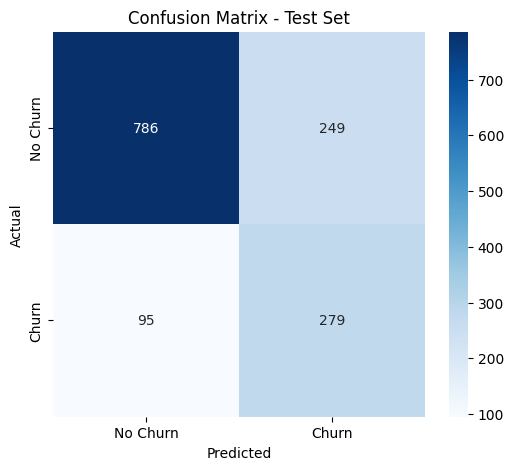

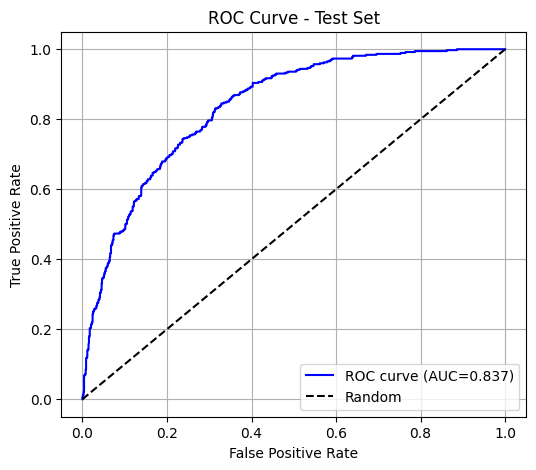

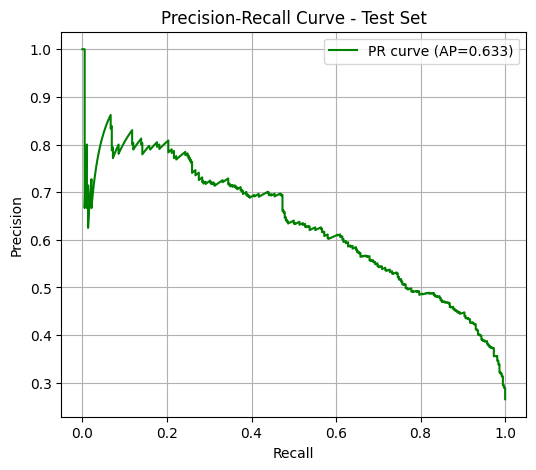

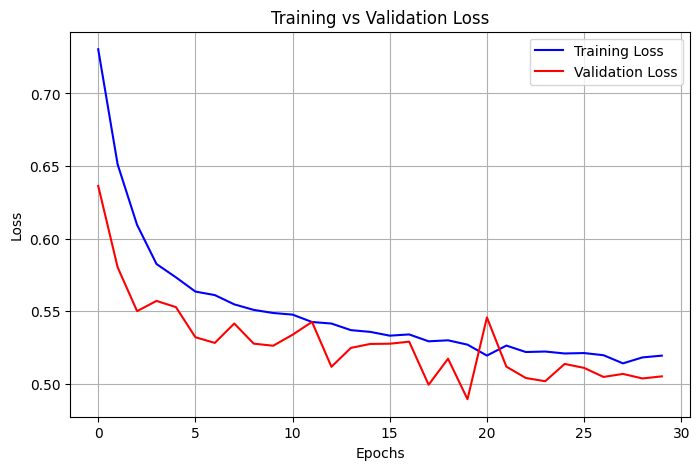

In [52]:
# Evaluate the model
results = evaluate_nn_model(
    model=model,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    history=history
)

## Check Inference Rows (Random 10 rows from Test Set)

In [54]:
# Set random seed for reproducibility
SEED = 42
np.random.seed(SEED)

# Combine X_test and y_test for easy sampling
test_data = X_test.copy()
test_data['target'] = y_test

# Randomly sample 10 rows stratified by class
sampled_rows = test_data.groupby('target', group_keys=False).apply(
    lambda x: x.sample(n=5 if len(x) > 5 else len(x), random_state=SEED)
)
if len(sampled_rows) > 10:
    sampled_rows = sampled_rows.sample(n=10, random_state=SEED)

# Separate features and labels
X_sample = sampled_rows.drop('target', axis=1)
y_sample = sampled_rows['target']

# Make predictions
predictions = model.predict(X_sample)

# Apply best threshold
pred_classes = (predictions > 0.5299999999999998).astype(int).ravel()

# Create results table
results_table = pd.DataFrame({
    'Actual': y_sample.values,
    'Predicted': pred_classes,
    'Correct': (pred_classes == y_sample.values)
})

# Display results
print(results_table)

36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Best Threshold based on validation F1: 0.6500000000000001
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
   Actual  Predicted  Correct
0       0          0     True
1       0          0     True
2       0          0     True
3       0          1    False
4       0          0     True
5       1          1     True
6       1          1     True
7       1          1     True
8       1          1     True
9       1          1     True


/tmp/ipython-input-4245731035.py:27: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled_rows = test_data.groupby('target', group_keys=False).apply(


## Model Summary

In [57]:
model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 32)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,365 (13.15 KB)

 Trainable params: 1,121 (4.38 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,244 (8.77 KB)

## Save Model

In [56]:
save_path = '/content/drive/MyDrive/NN_Model/Final_NN_model/'

import joblib
# Create folder if it doesn't exist
os.makedirs(save_path, exist_ok=True)

# Save trained model
model.save(os.path.join(save_path, 'churn_model.h5'))

# Save best threshold
joblib.dump(best_threshold, os.path.join(save_path, 'best_threshold.pkl'))

# Save training history
joblib.dump(history.history, os.path.join(save_path, 'history.pkl'))

print("All objects saved to Drive successfully!")


All objects saved to Drive successfully!
